## Road Traffic Accident (RTA) Prediction Model

## Step 1 — Load the CSV(s)

In [60]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

df_raw = pd.read_csv("/content/drive/MyDrive/RTA_Dataset (1).csv")

print("Dataset shape:", df_raw.shape)
df_raw.head()

Dataset shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## Step 2 — Understand the Dataset

### 2.1 Basic shape & structure

In [62]:
print(f"Number of rows    : {df_raw.shape[0]}")
print(f"Number of columns : {df_raw.shape[1]}")
print("\nColumn names:")
print(df_raw.columns.tolist())

Number of rows    : 12316
Number of columns : 32

Column names:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


### 2.2 Data types

In [63]:
dtype_df = pd.DataFrame({
    "Datatype": df_raw.dtypes,
    "Number of Unique categories within each column": df_raw.nunique()
})
dtype_df

,Datatype,Number of Unique categories within each column
Time,object,1074
Day_of_week,object,7
Age_band_of_driver,object,5
Sex_of_driver,object,3
Educational_level,object,7
Vehicle_driver_relation,object,4
Driving_experience,object,7
Type_of_vehicle,object,17
Owner_of_vehicle,object,4
Service_year_of_vehicle,object,6


### 2.3 Missing values

In [64]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({
    "Missing_count": missing,
    "Missing_percentage": missing_pct
}).query("Missing_count > 0").sort_values("Missing_count", ascending=False)

missing_summary

,Missing_count,Missing_percentage
Defect_of_vehicle,4427,35.95
Service_year_of_vehicle,3928,31.89
Work_of_casuality,3198,25.97
Fitness_of_casuality,2635,21.39
Type_of_vehicle,950,7.71
Types_of_Junction,887,7.20
Driving_experience,829,6.73
Educational_level,741,6.02
Vehicle_driver_relation,579,4.70
Owner_of_vehicle,482,3.91


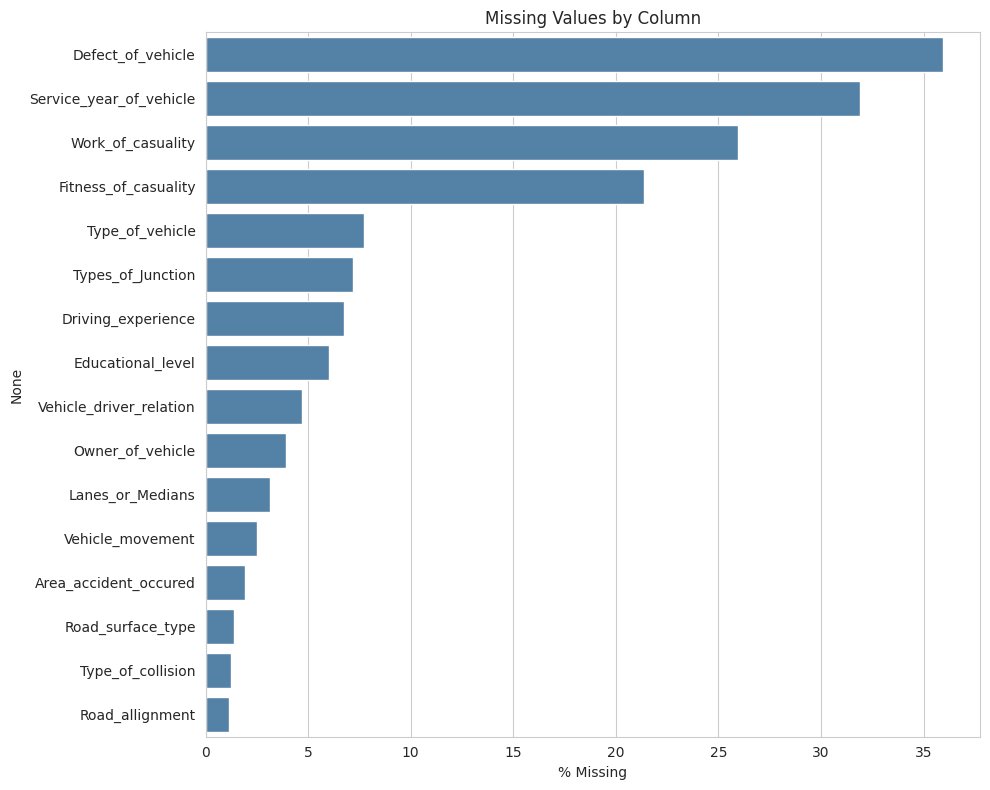

In [65]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_summary["Missing_percentage"], y=missing_summary.index, color="steelblue")
plt.xlabel("% Missing")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

### 2.4 Target variable

In [66]:
print("Raw target classes:")
print(df_raw["Accident_severity"].value_counts())
print("\nClass proportions (%):")
print((df_raw["Accident_severity"].value_counts(normalize=True) * 100).round(2))

Raw target classes:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Class proportions (%):
Accident_severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: proportion, dtype: float64


### 2.5 Duplicate rows

In [67]:
n_dupes = df_raw.duplicated().sum()
print(f"Number of fully duplicated rows: {n_dupes}")

Number of fully duplicated rows: 0


### 2.6 Quick statistical summary (numeric columns)

In [68]:
df_raw.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("RTA_Dataset (1).csv")

# Features you care about
features = [
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Types_of_Junction",
    "Light_conditions",
    "Weather_conditions",
    "Hour",
    "Day_of_week",
    "Age_band_of_driver",
    "Pedestrian_movement",
    "Type_of_collision"
]

# Print unique values for each feature
for feature in features:
    print(f"{feature}: {df[feature].unique()}")

## Step 3 — Preprocessing

### 3.1 Handling missing values

In [69]:
df = df_raw.copy()

In [70]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns

# Impute categorical columns with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numeric columns with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Check if missing values remain
print("Missing values remaining : ", int(df.isnull().sum().any()))


Missing values remaining :  0


### 3.2 Converting dates and times
`Time` is a string like `17:02:00`. We convert it to a proper time object and derive an `Hour` and a `Time_of_day` bucket used later in EDA.

In [71]:
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.time
df["Hour"] = df["Time"].apply(lambda t: t.hour)

def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time_of_day"] = df["Hour"].apply(time_of_day)

# Day_of_week is already categorical text (Monday..Sunday) — enforce a sensible order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day_of_week"] = pd.Categorical(df["Day_of_week"], categories=day_order, ordered=True)

df[["Time", "Hour", "Time_of_day", "Day_of_week"]].head()

,Time,Hour,Time_of_day,Day_of_week
0,17:02:00,17,Evening,Monday
1,17:02:00,17,Evening,Monday
2,17:02:00,17,Evening,Monday
3,01:06:00,1,Night,Sunday
4,01:06:00,1,Night,Sunday


### 3.3 Encoding categorical variables
We keep a **human-readable copy** (`df`) for EDA/plots, and build a **separate numerically-encoded copy** (`df_model`) for any downstream modeling.

In [72]:
df_copy = df.copy()

In [73]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate features and target
X = df_copy.drop(columns=['Accident_severity'])
y = df_copy['Accident_severity']

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Scale numeric columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Clean strings: strip spaces, unify case
df_copy['Accident_severity'] = df_copy['Accident_severity'].str.strip().str.title()

severity_map = {
    "Slight Injury": 0,
    "Serious Injury": 1,
    "Fatal Injury": 2   # note capital I
}

y = df_copy['Accident_severity'].map(severity_map)


# Combine encoded X and y into one DataFrame
df_model = X.copy()
df_model['Accident_severity'] = y

print(df_model.head())

   Time  Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0   735            1                   0              1                  0   
1   735            1                   1              1                  4   
2   735            1                   0              1                  4   
3    42            3                   0              1                  4   
4    42            3                   0              1                  4   

   Vehicle_driver_relation  Driving_experience  Type_of_vehicle  \
0                        0                   0                0   
1                        0                   3               11   
2                        0                   0                5   
3                        0                   2               11   
4                        0                   1                0   

   Owner_of_vehicle  Service_year_of_vehicle  ...  Sex_of_casualty  \
0                 3                        3  ...         

### 3.5 Feature selection
Drop identifier-like / near-duplicate-information columns and check correlation of remaining features with the target.

In [74]:
# Casualty-level fields describe the outcome/victim rather than pre-crash conditions —
# drop them if the goal is to predict severity from *conditions*, keep them if analysing outcomes.
outcome_leak_cols = ["Casualty_class", "Sex_of_casualty", "Age_band_of_casualty",
                      "Casualty_severity", "Work_of_casuality", "Fitness_of_casuality"]

df_features = df_model.drop(columns=outcome_leak_cols)

Correlation with numeric columns :
 Accident_severity              1.000000
Number_of_casualties           0.045339
Time_of_day                    0.032032
Time                           0.020982
Area_accident_occured          0.018374
Hour                           0.018065
Lanes_or_Medians               0.011844
Vehicle_driver_relation        0.011253
Owner_of_vehicle               0.010960
Vehicle_movement               0.010386
Types_of_Junction              0.008861
Road_allignment                0.005967
Road_surface_type              0.004510
Type_of_vehicle                0.003709
Day_of_week                    0.002730
Educational_level              0.001471
Service_year_of_vehicle       -0.000393
Driving_experience            -0.000509
Defect_of_vehicle             -0.001889
Road_surface_conditions       -0.004579
Sex_of_driver                 -0.004977
Cause_of_accident             -0.008040
Weather_conditions            -0.010172
Pedestrian_movement           -0.013082
Age_

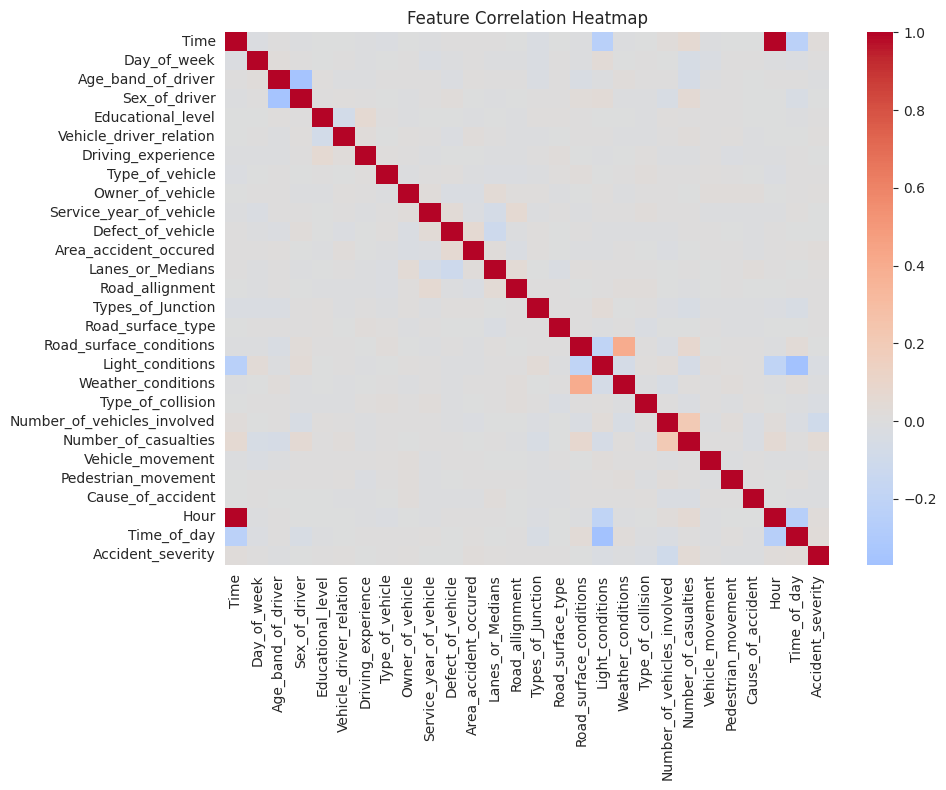

In [75]:
# Finding Correlation
corr = df_features.corr(numeric_only=True)["Accident_severity"].sort_values(ascending=False)
print("Correlation with numeric columns :\n", corr)

plt.figure(figsize=(10,8))
sns.heatmap(df_features.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### 3.6 Addressing class imbalance

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Class proportions (%):
Accident_severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: proportion, dtype: float64


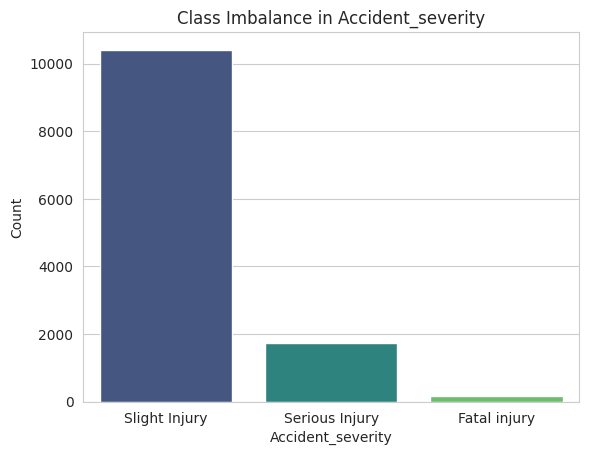

In [76]:
print(df["Accident_severity"].value_counts())
print("\nClass proportions (%):")
print((df["Accident_severity"].value_counts(normalize=True) * 100).round(2))

sns.countplot(x=df["Accident_severity"],
              order=["Slight Injury", "Serious Injury", "Fatal injury"],
              palette="viridis")
plt.title("Class Imbalance in Accident_severity")
plt.ylabel("Count")
plt.show()

In [77]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # pip install imbalanced-learn

X = df_features.drop(columns=["Accident_severity", "Time"])
y = df_features["Accident_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE :", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 8331, 1: 1394, 2: 127}
After SMOTE : {0: 8331, 1: 8331, 2: 8331}


## Step 4 — Exploratory Data Analysis (EDA)

### 4.1 Accident severity distribution

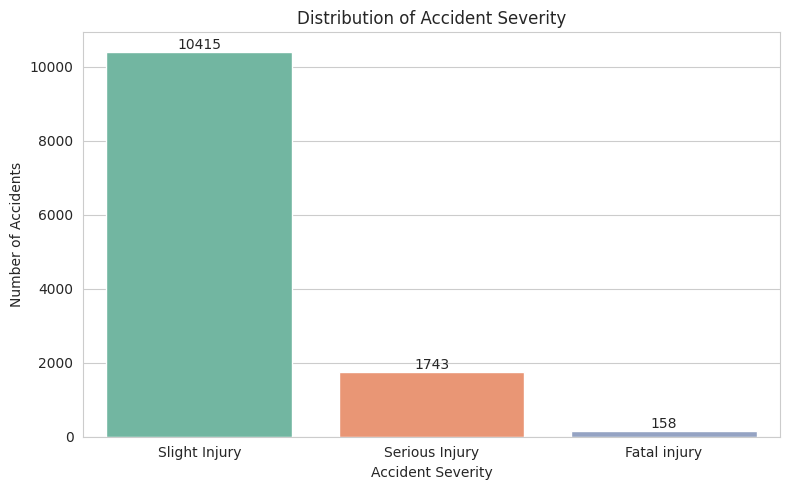

In [78]:
plt.figure(figsize=(8, 5))
order = ["Slight Injury", "Serious Injury", "Fatal injury"]
ax = sns.countplot(x="Accident_severity", data=df, order=order, palette="Set2")
plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 4.2 Weather conditions vs severity

<Figure size 1200x600 with 0 Axes>

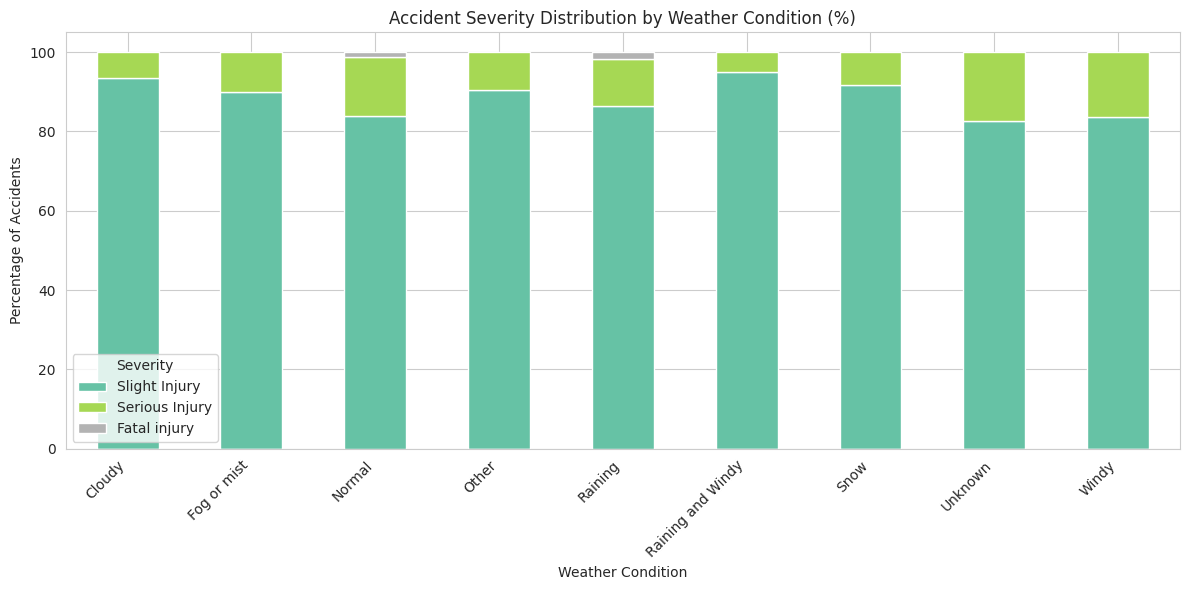

In [79]:
plt.figure(figsize=(12, 6))
weather_severity = pd.crosstab(df["Weather_conditions"], df["Accident_severity"], normalize="index") * 100
weather_severity = weather_severity[order]
weather_severity.plot(kind="bar", stacked=True, colormap="Set2", figsize=(12, 6))
plt.title("Accident Severity Distribution by Weather Condition (%)")
plt.xlabel("Weather Condition")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

### 4.3 Lighting conditions

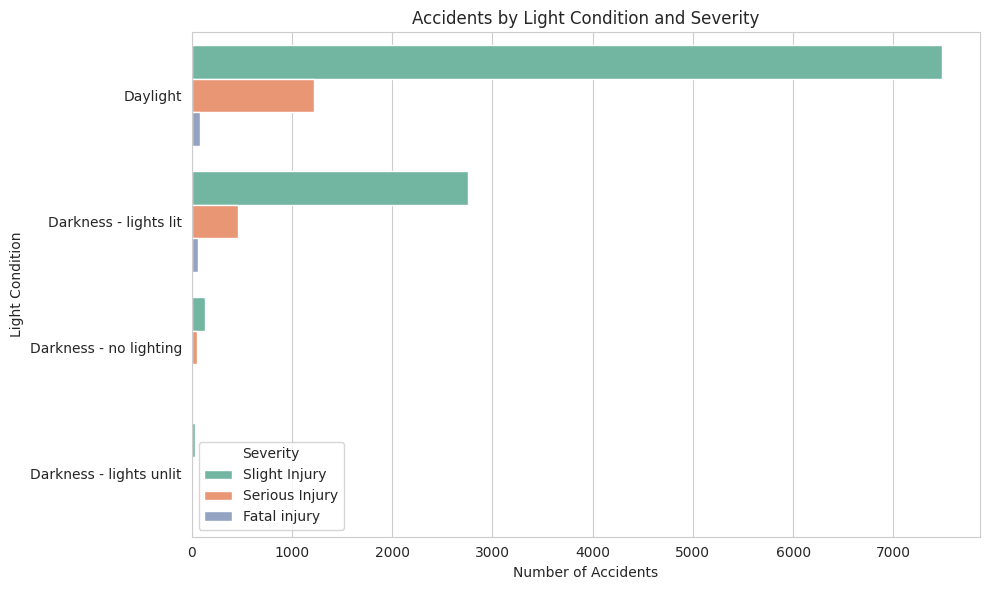

In [80]:
plt.figure(figsize=(10, 6))
sns.countplot(y="Light_conditions", data=df,
              order=df["Light_conditions"].value_counts().index,
              hue="Accident_severity", hue_order=order, palette="Set2")
plt.title("Accidents by Light Condition and Severity")
plt.xlabel("Number of Accidents")
plt.ylabel("Light Condition")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

### 4.4 Road type / surface analysis

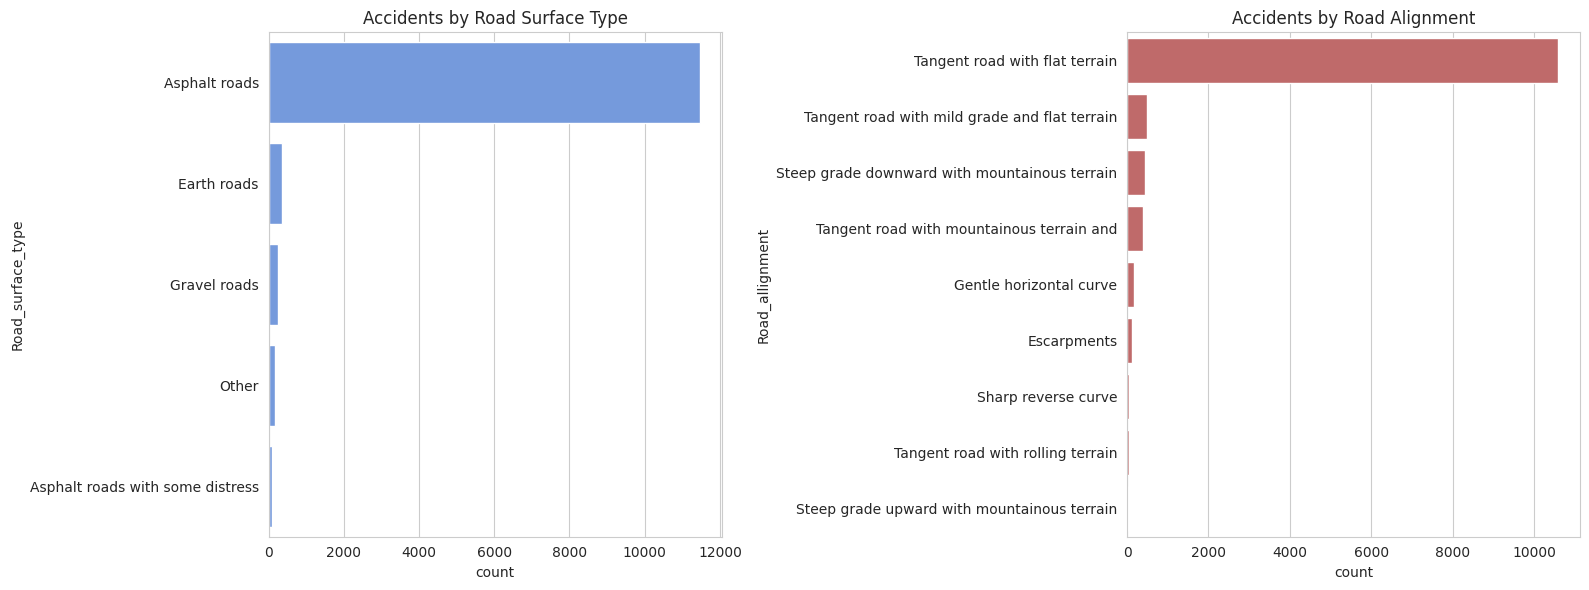

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(y="Road_surface_type", data=df,
              order=df["Road_surface_type"].value_counts().index,
              ax=axes[0], color="cornflowerblue")
axes[0].set_title("Accidents by Road Surface Type")

sns.countplot(y="Road_allignment", data=df,
              order=df["Road_allignment"].value_counts().index,
              ax=axes[1], color="indianred")
axes[1].set_title("Accidents by Road Alignment")

plt.tight_layout()
plt.show()

### 4.5 Number of Vehicles involved analysis

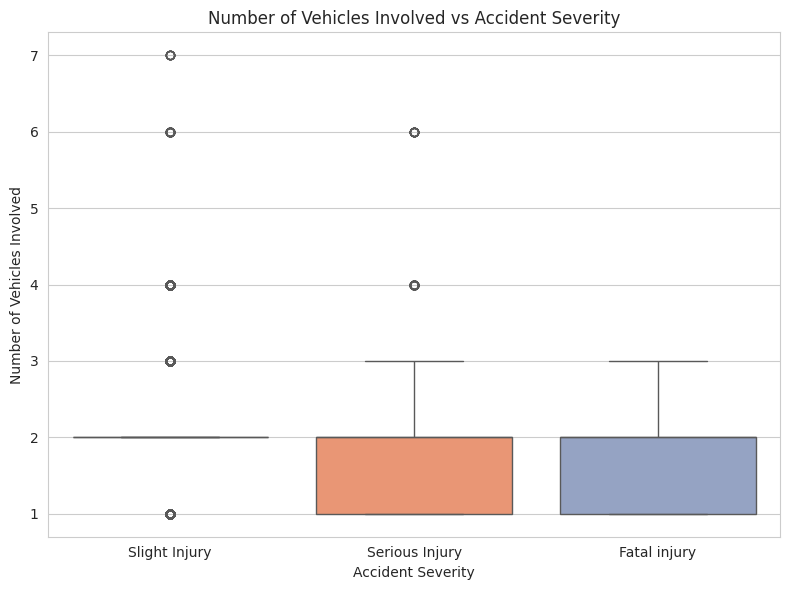

In [82]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Accident_severity", y="Number_of_vehicles_involved", data=df, order=order, palette="Set2")
plt.title("Number of Vehicles Involved vs Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Vehicles Involved")
plt.tight_layout()
plt.show()

### 4.6 Day of the week

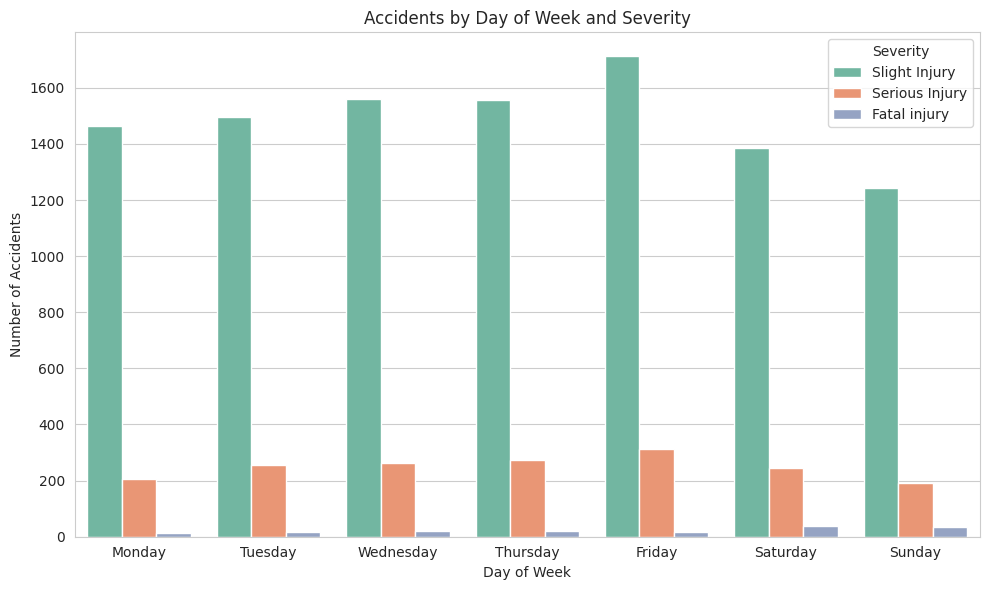

In [83]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Day_of_week", data=df, order=day_order, hue="Accident_severity",
              hue_order=order, palette="Set2")
plt.title("Accidents by Day of Week and Severity")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

### 4.7 Time of day

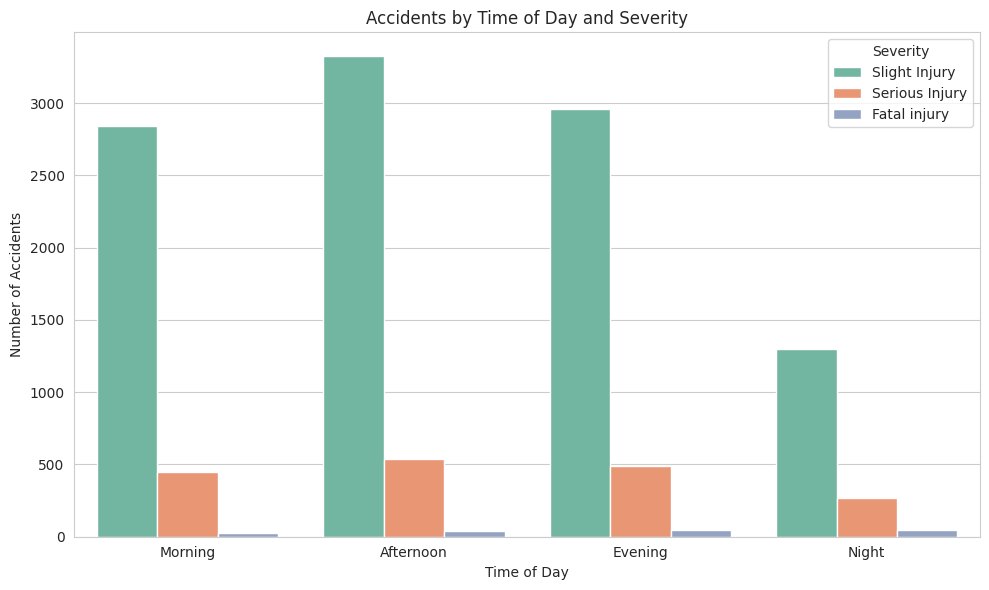

In [84]:
plt.figure(figsize=(10, 6))
tod_order = ["Morning", "Afternoon", "Evening", "Night"]
sns.countplot(x="Time_of_day", data=df, order=tod_order, hue="Accident_severity",
              hue_order=order, palette="Set2")
plt.title("Accidents by Time of Day and Severity")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

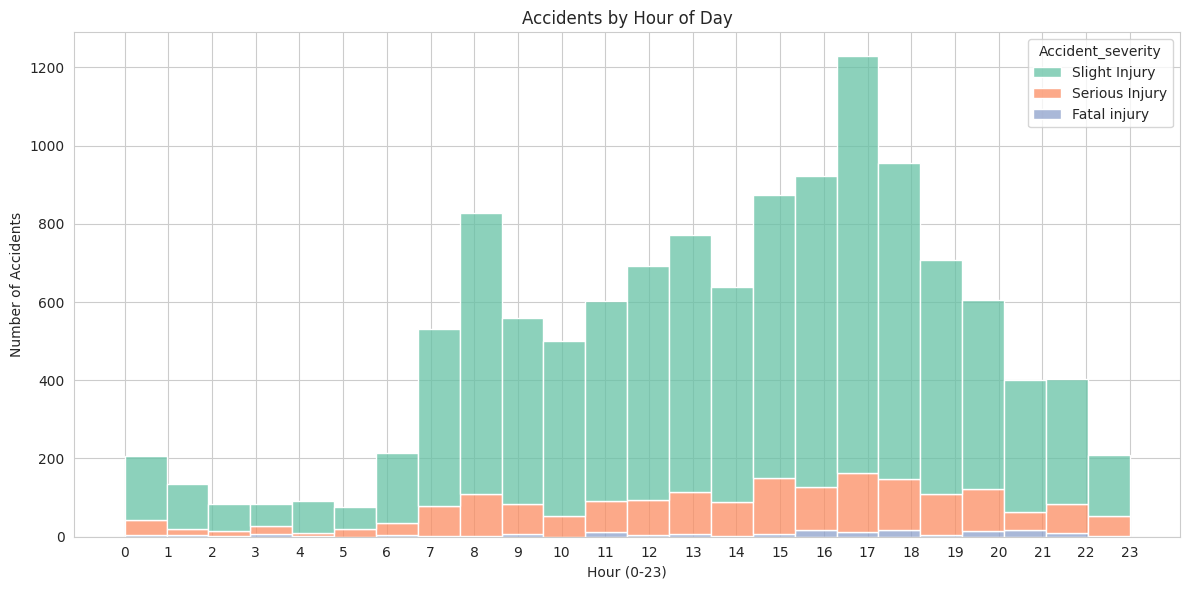

In [85]:
# Hourly distribution (finer granularity than the 4 buckets above)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="Hour", hue="Accident_severity", hue_order=order,
             multiple="stack", bins=24, palette="Set2")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 5. Model 

### 5.1 Creating and Comparing baseline performance

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost" : XGBClassifier(random_state=42, eval_metric="mlogloss",
            use_label_encoder=False, n_jobs=-1)
}



In [87]:
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

results = []

for name, model in models.items():
    # Raw
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Data": "Raw",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted")
    })

    # SMOTE
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Data": "SMOTE",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted")
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values(["Model", "Data"]).reset_index(drop=True)
results_df

,Model,Data,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
0,Decision Tree,Raw,0.758929,0.440331,0.431360,0.767371
1,Decision Tree,SMOTE,0.754058,0.469395,0.450872,0.765006
2,Gradient Boosting,Raw,0.849838,0.348451,0.336537,0.789552
3,Gradient Boosting,SMOTE,0.809659,0.450215,0.418013,0.784681
4,KNN,Raw,0.834416,0.335216,0.316742,0.775086
5,KNN,SMOTE,0.512987,0.349508,0.301003,0.590377
6,Logistic Regression,Raw,0.845373,0.333173,0.305403,0.774910
7,Logistic Regression,SMOTE,0.543831,0.411958,0.320247,0.620009
8,Random Forest,Raw,0.851461,0.347500,0.333811,0.789117
9,Random Forest,SMOTE,0.846185,0.406080,0.429893,0.802291


### 5.2 Selecting best model

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = XGBClassifier(random_state=42, eval_metric="mlogloss",
            use_label_encoder=False, n_jobs=-1)

best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

print("Best model is XGBoost (Raw)\n")

# Metrics
print("Accuracy:", accuracy_score(y_test, preds))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, preds))
print("F1 Macro:", f1_score(y_test, preds, average="macro"))
print("F1 Weighted:", f1_score(y_test, preds, average="weighted"))
print("\nClassification Report:\n", classification_report(y_test, preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))

Best model is XGBoost (Raw)

Accuracy: 0.8518668831168831
Balanced Accuracy: 0.4522809212744315
F1 Macro: 0.496559047253416
F1 Weighted: 0.8087259390956547

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      2084
           1       0.56      0.11      0.19       349
           2       0.73      0.26      0.38        31

    accuracy                           0.85      2464
   macro avg       0.71      0.45      0.50      2464
weighted avg       0.82      0.85      0.81      2464


Confusion Matrix:
 [[2051   30    3]
 [ 309   40    0]
 [  21    2    8]]


### 5.3 Cross-validation

In [89]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

# Cross-validation
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Print mean scores
for metric in scoring.keys():
    print(f"{metric}: {cv_results['test_' + metric].mean():.4f}")

accuracy: 0.8473
balanced_accuracy: 0.4041
f1_macro: 0.4338
f1_weighted: 0.8034


### 5.4 Hyperparameter tuning

In [90]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

# Grid search
grid_search = GridSearchCV(
    estimator=best_model,   
    param_grid=param_grid,
    scoring="f1_macro",   # you can also use "balanced_accuracy"
    cv=skf,
    verbose=2,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Macro:", grid_search.best_score_)
 

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}
Best F1 Macro: 0.42611885966042606


In [91]:
best_params = grid_search.best_params_
best_model = XGBClassifier(**best_params, random_state=42, eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1)
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [92]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))
print("F1 Weighted:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8530844155844156
Balanced Accuracy: 0.4315752890122393
F1 Macro: 0.47564317849261134
F1 Weighted: 0.8086654405177528

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      2084
           1       0.59      0.11      0.19       349
           2       0.86      0.19      0.32        31

    accuracy                           0.85      2464
   macro avg       0.77      0.43      0.48      2464
weighted avg       0.82      0.85      0.81      2464


Confusion Matrix:
 [[2056   27    1]
 [ 309   40    0]
 [  24    1    6]]


### 6. Interpretability & Feature Selection

### 6.1 Feature importance

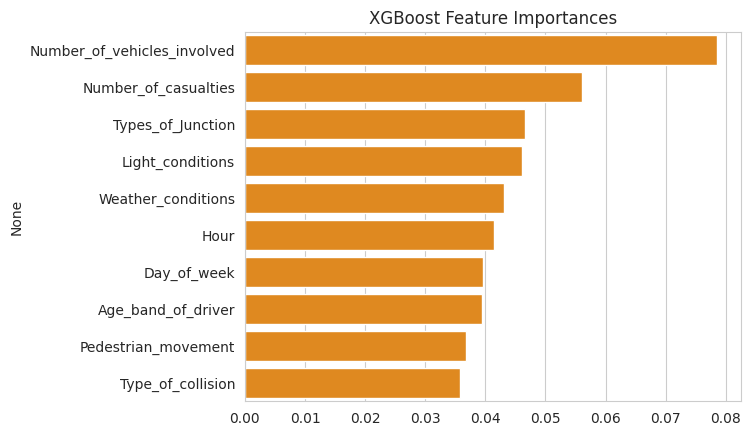

In [93]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

sns.barplot(x=importances.values[:10], y=importances.index[:10], color="darkorange")
plt.title("XGBoost Feature Importances")
plt.show()

In [94]:
top10_features = importances.index[:10].tolist()
print("Top 10 features:", top10_features)

Top 10 features: ['Number_of_vehicles_involved', 'Number_of_casualties', 'Types_of_Junction', 'Light_conditions', 'Weather_conditions', 'Hour', 'Day_of_week', 'Age_band_of_driver', 'Pedestrian_movement', 'Type_of_collision']


In [95]:
# Filter train/test sets to only top 10 features
X_train_top10 = X_train[top10_features]
X_test_top10  = X_test[top10_features]

# Train XGBoost with tuned parameters
xgb_top10 = XGBClassifier(
    **best_params,   # use your tuned hyperparameters
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_jobs=-1
)

xgb_top10.fit(X_train_top10, y_train)

# Predictions
y_pred_top10 = xgb_top10.predict(X_test_top10)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_top10))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_top10))
print("F1 Macro:", f1_score(y_test, y_pred_top10, average="macro"))
print("F1 Weighted:", f1_score(y_test, y_pred_top10, average="weighted"))

print("\nClassification Report:\n", classification_report(y_test, y_pred_top10))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_top10))


Accuracy: 0.8571428571428571
Balanced Accuracy: 0.5044271774431572
F1 Macro: 0.5583673242684868
F1 Weighted: 0.8241412678428439

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      2084
           1       0.58      0.18      0.28       349
           2       0.73      0.35      0.48        31

    accuracy                           0.86      2464
   macro avg       0.73      0.50      0.56      2464
weighted avg       0.83      0.86      0.82      2464


Confusion Matrix:
 [[2038   43    3]
 [ 285   63    1]
 [  18    2   11]]


In [96]:
# Full model metrics (already computed earlier)
print("Full model F1 Macro:", f1_score(y_test, y_pred, average="macro"))

# Top 10 model metrics
print("Top 10 model F1 Macro:", f1_score(y_test, y_pred_top10, average="macro"))

results = {
    "Model": ["Full Features", "Top 10 Features"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_top10)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_top10)
    ],
    "F1 Macro": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_top10, average="macro")
    ],
    "F1 Weighted": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred_top10, average="weighted")
    ]
}

print(pd.DataFrame(results))


Full model F1 Macro: 0.47564317849261134
Top 10 model F1 Macro: 0.5583673242684868
             Model  Accuracy  Balanced Accuracy  F1 Macro  F1 Weighted
0    Full Features  0.853084           0.431575  0.475643     0.808665
1  Top 10 Features  0.857143           0.504427  0.558367     0.824141


In [97]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_top10 = cross_validate(
    xgb_top10,
    X_train_top10,
    y_train,
    cv=skf,
    scoring={"accuracy":"accuracy","balanced_accuracy":"balanced_accuracy","f1_macro":"f1_macro","f1_weighted":"f1_weighted"},
    n_jobs=-1
)

print("CV Accuracy:", cv_results_top10['test_accuracy'].mean())
print("CV Balanced Accuracy:", cv_results_top10['test_balanced_accuracy'].mean())
print("CV F1 Macro:", cv_results_top10['test_f1_macro'].mean())
print("CV F1 Weighted:", cv_results_top10['test_f1_weighted'].mean())


CV Accuracy: 0.8664228264144821
CV Balanced Accuracy: 0.5176216633057769
CV F1 Macro: 0.5837992174586975
CV F1 Weighted: 0.8357800536822957


### 6.2 SHAP Analysis

In [98]:
!pip install shap
import shap

# Use your trained top-10 feature model
explainer = shap.TreeExplainer(xgb_top10)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test[top10_features])


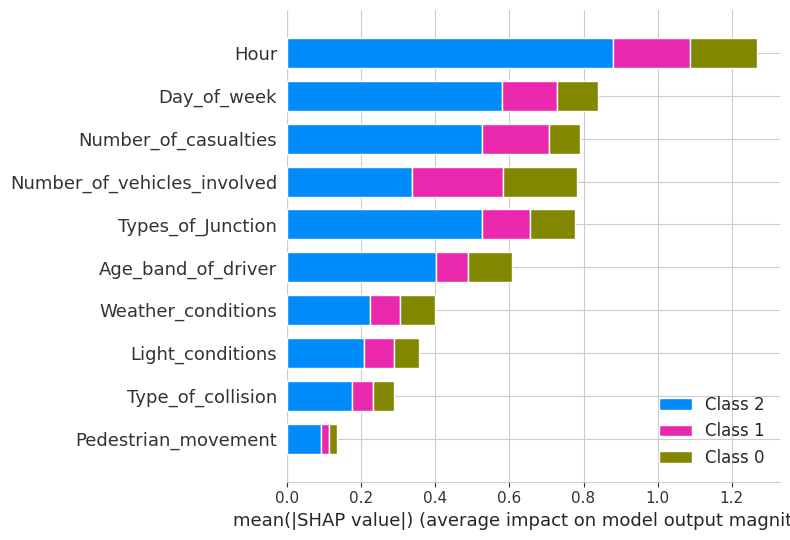

In [99]:
# Average absolute SHAP values per feature
shap.summary_plot(shap_values, X_test[top10_features], plot_type="bar")


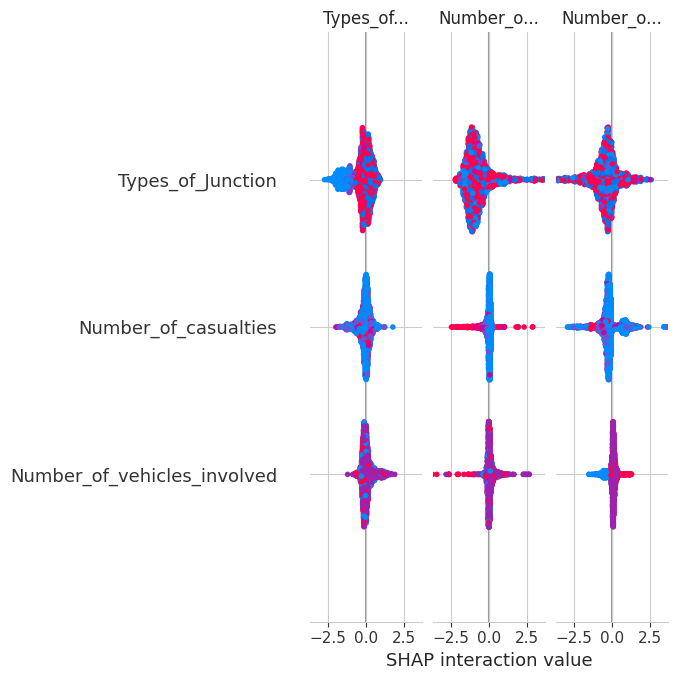

In [100]:
shap.summary_plot(shap_values, X_test[top10_features])


### 7. Final Deployment

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Restrict dataset to only those 10
X = df[top10_features]

severity_map = {"Slight Injury": 0, "Serious Injury": 1, "Fatal injury": 2}
y = df['Accident_severity'].map(severity_map)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate categorical vs numeric among the 10
cat_cols = [c for c in top10_features if X_train[c].dtype == "object"]
num_cols = [c for c in top10_features if X_train[c].dtype in ["int64","float64"]]

# Preprocessor only for these 10
preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Final pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False,
        n_jobs=-1
    ))
])

final_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Types_of_Junction',
                                                   'Light_conditions',
                                                   'Weather_conditions',
                                                   'Age_band_of_driver',
                                                   'Pedestrian_movement',
                                                   'Type_of_collision']),
                                                 ('num', StandardScaler(),
                                                  ['Number_of_vehicles_involved',
                                                   'Number_of_casualties',
                                                   'Hour']...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [102]:
y_pred = final_pipeline.predict(X_test)

print("="*70)
print("FINAL DEPLOYMENT MODEL")
print("="*70)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report")
print("="*70)

print(classification_report(y_test, y_pred))

FINAL DEPLOYMENT MODEL
Accuracy: 0.8543
Balanced Accuracy: 0.4693
Macro F1: 0.5217

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2064
           1       0.70      0.15      0.25       363
           2       0.77      0.27      0.40        37

    accuracy                           0.85      2464
   macro avg       0.78      0.47      0.52      2464
weighted avg       0.84      0.85      0.81      2464



In [104]:
import joblib

# Save the preprocessor part into Drive
joblib.dump(preprocessor, "/content/drive/MyDrive/preprocessor.joblib")

# Save the XGBClassifier part into Drive
final_pipeline.named_steps["classifier"].save_model("/content/drive/MyDrive/xgb_model.json")